# Restaurant Tips Analysis

## Business Context
Understanding tipping behavior can provide insights into customer spending patterns and help restaurants better evaluate service performance and revenue dynamics.

## Objective
The goal of this analysis is to explore the relationship between total bill, tip amount, and customer characteristics such as time, day, and group size.

## Dataset
The dataset is sourced from the Seaborn repository and contains information on restaurant bills, tips, and customer attributes.
Data Source: [Seaborn tips dataset](https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv)

## Data Inspection

**Goal:**
Understand the structure of the dataset before performing any analysis.

**Steps:**
- Load dataset into pandas DataFrame
- Inspect first rows
- Check column types and missing values
- Generate summary statistics

In [1]:
# Import library pandas and matplot
import pandas as pd
import matplotlib.pyplot as plt

print("Enviroment is ready. Project started.")

# Load dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

# Save dataset
df.to_csv("../data/tips.csv", index=False)

# Inspect
print("First 5 rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nDataset description:")
print(df.describe())

Enviroment is ready. Project started.
First 5 rows:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None

Dataset description:
       total_bill         tip        size
coun

## Data Cleaning

**Goal:**
Check data quality and prepare the dataset for analysis.

**Steps:**
1. Check missing values
2. Check duplicate rows
3. Validate data types
4. Perform basic cleaning

In [2]:
# Check missing value
df.isnull().sum()

# Check duplicates
df.duplicated().sum()

# Remove duplicates
df = df.drop_duplicates()

# Check duplicates in order to make sure that they all have been successfully removed
df.duplicated().sum()

# Check number of rows after removing duplicates
df.shape

# Check data types
df.dtypes

# Save the cleaned dataset
df.to_csv("tips_cleaned.csv", index=False)

### Observations:

1. No missing values were detected in the dataset.
2. One duplicate row was detected in the dataset.
3. The duplicate entry is removed using "drop_duplicates()"
4. After removing one duplicate row, the dataset contains 243 observations.
5. The data types of all variables appear appropriate for analysis.
6. A cleaned version of the dataset was saved for further analysis.

## Exploratory Data Analysis (EDA)

**Goal:**
Explore the dataset to understand distributions, relationships, and patterns in the data.

**Steps:**
1. Compute summary statistics for numeric variables ('total_bill', 'tip', 'size').
2. Analyze categorical variables ('day', 'time', 'sex', 'smoker') and their distributions.
3. Examine relationships between key variables (e.g., 'total_bill' vs 'tip', 'size' vs 'tip').
4. Visualize distributions and relationships using plots (histograms, boxplots, scatterplots).
5. Identify patterns, trends, or anomalies that may influence further analysis.

### Numeric Summary
The summary statistics provide insights into the distribution of numeric variables like total_bill, tip, and size.

In [3]:
# Summary statistics for numeric variables
df.describe()

,total_bill,tip,size
count,243.000000,243.000000,243.000000
mean,19.813868,3.002387,2.572016
std,8.910071,1.385002,0.952356
min,3.070000,1.000000,1.000000
25%,13.380000,2.000000,2.000000
50%,17.810000,2.920000,2.000000
75%,24.175000,3.575000,3.000000
max,50.810000,10.000000,6.000000


### Categorical Summary
This shows the frequency of each category for day, time, sex and smoker status.

In [4]:
# Count of each category
df['day'].value_counts()
df['time'].value_counts()
df['sex'].value_counts()
df['smoker'].value_counts()

# Average tip by day
df.groupby("day")["tip"].mean()

smoker
No     151
Yes     92
Name: count, dtype: int64

### Observation
The average tip on Friday is approximately **2.73**, on Saturday it is about **2.99**, on Sunday it is around **3.26**, while on Thursday it is about **2.78**.
This suggests that customers tend to leave a slightly higher tips on Sunday among all of four days.

In [6]:
# Average tip by time
df.groupby("time")["tip"].mean()

time
Dinner    3.102670
Lunch     2.738955
Name: tip, dtype: float64

### Observation
The average tip during dinner is approximately **3.10**, while during lunch it is about **2.74**.
This suggests that customers tend to leave slightly higher tips during dinner compared to lunch.

In [7]:
# Average total_bill by time
df.groupby("time")["total_bill"].mean()

time
Dinner    20.797159
Lunch     17.230896
Name: total_bill, dtype: float64

### Observation
The average total bill during dinner is approximately **20.80**, while during lunch it is about **17.23**. This suggests that customers spend more during dinner compared with lunch. 
This may partly explain why the average tip during dinner is higher, since larger bills are typically associated with higher tipping amounts.

In [8]:
## Visualization

# Import library seaborn
import seaborn as sns
import matplotlib.pyplot as plt

import sys
print(sys.executable)

import sys
!{sys.executable} -m pip install seaborn

/opt/homebrew/opt/python@3.10/bin/python3.10

[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip


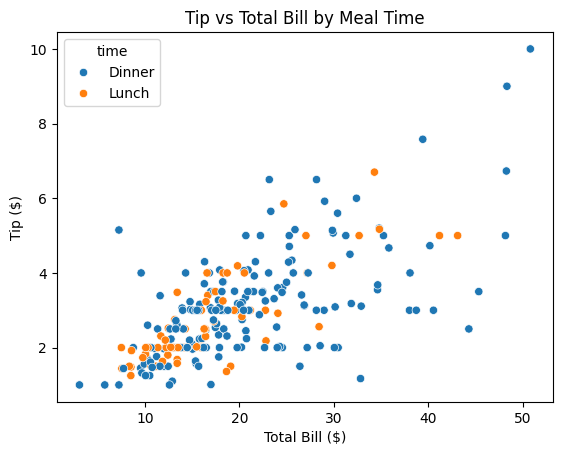

In [9]:
# Scatter plot: total_bill vs tip, color by time
sns.scatterplot(x='total_bill', y='tip', hue='time', data=df)
plt.title("Tip vs Total Bill by Meal Time")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()

### Observations:
1. Tips generally increase as total bill increases, indicating a positive relationship between bill size and tipping amount.
2. The scatterplot dose not reveal extreme outliers, and the tipping behavior seems relatively consistent across the dataset.
3. The difference in tipping behavior between lunch and dinner is not very pronounced in the scatterplot, suggesting that meal time alone may not strongly influence tipping patterns.

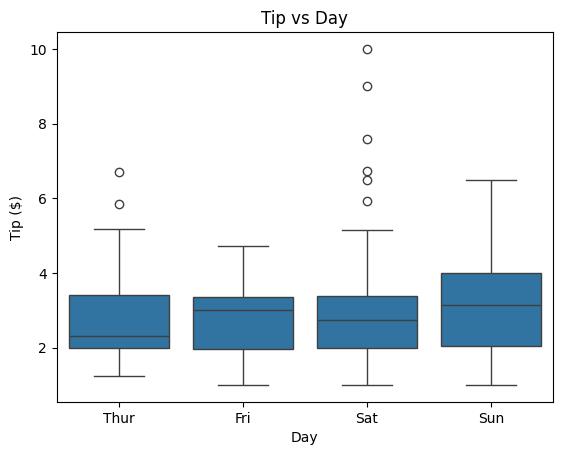

In [10]:
# Boxplot: tip by day
sns.boxplot(x='day', y='tip', data=df, order=["Thur", "Fri", "Sat", "Sun"])
plt.title("Tip vs Day")
plt.xlabel("Day")
plt.ylabel("Tip ($)")
plt.show()

### Observations:
1. Saturday's tip distribution shows the highest number of outliers.
2. Sunday exhibits a higher median tip value compared to other days.


## Tip Rate Analysis

**Goal:**
Analyze tipping behavior relative to the total bill by examning the tipping percentage.

**Steps:**
1. Create a new variable 'tip_rate' definded as 'tip/total_bill'.
2. Examine the overall distribution of 'tip_rate'.
3. Compare tipping percentages across different categoties (e.g., lunch vs dinner).
4. Visualize the distribution of 'tip_rate' using histograms and boxplots.
5. Identify patterns in tipping behavior based on relative tip amounts rather than absolute tip values.

In [11]:
# Create tip rate column
df["tip_rate"] = df["tip"] / df["total_bill"]

# Inspect
df["tip_rate"].describe()

count    243.000000
mean       0.160831
std        0.061197
min        0.035638
25%        0.128833
50%        0.155219
75%        0.191746
max        0.710345
Name: tip_rate, dtype: float64

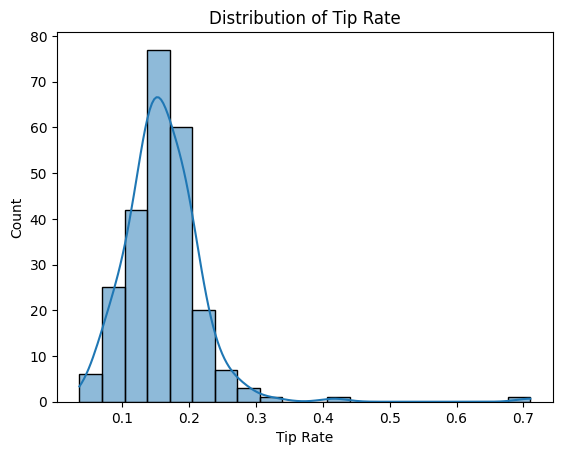

In [12]:
# Histogram
sns.histplot(df["tip_rate"], bins=20, kde=True)
plt.title("Distribution of Tip Rate")
plt.xlabel("Tip Rate")
plt.show()

### Observation:

1. The average tip rate in the dataset is approximately **16%**.
2. The histogram show that most tip rates fall between approximately 10% and 20%, indicating a relatively consistent tipping pattern among customers.


In [13]:
# Group analysis
df.groupby("time")["tip_rate"].mean()

# Boxplot: tip_rate by time
sns.boxplot(x="time", y="tip_rate", data=df)
plt.title("Tip Rate by Meal Time")
plt.show()

time
Dinner    0.159518
Lunch     0.164281
Name: tip_rate, dtype: float64

### observations:

1. The average tip rate during dinner is approximately **0.159**, while it is **0.164** during lunch. This suggests that the higher tip amounts observed during dinner are primarily associated with higher total bill amounts rather than a higher tipping tendency among cumstomers.
2. The boxplot confirms the result of the group analysis. Aside from a few outliers, most tip rates fall within a similar range for both dinner and lunch, indicating that tipping percentages remain relatively consistent across meal times.

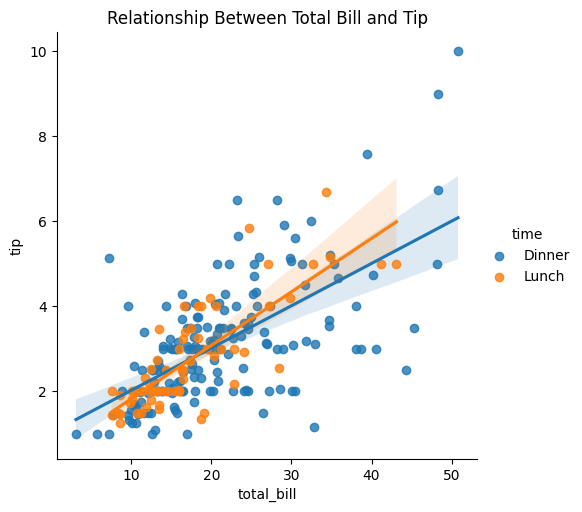

In [15]:
# Regression plot: tip vs total_bill
sns.lmplot(x="total_bill", y="tip", hue="time", data=df)
plt.title("Relationship Between Total Bill and Tip")
plt.show()

### Observations

1. The regression lines show a clear positive relationship between total_bill and tip, indicating that higher bills are generally associated with higher tip amounts.
2. The regression lines for lunch and dinner appear very similar in slope, suggesting that the relationship between bill size and tipping behavior is consistent across meal times.
3. Although dinner bills tend to be higher overall, the tipping pattern relative to the bill amount remains relatively stable for both lunch and dinner.

These observations are consistent with the previous tip rate analysis, which showed that tipping percentages remain relatively stable across meal times.

In [16]:
# Group analysis
df.groupby("size")["tip_rate"].mean()

# Boxplot: tip_rate by size
sns.boxplot(x="size", y="tip_rate", data=df)
plt.title("Tip Rate by Group Size")
plt.xlabel("Group Size")
plt.ylabel("Tip Rate")
plt.show()

size
1    0.217292
2    0.165796
3    0.152157
4    0.145949
5    0.141495
6    0.156229
Name: tip_rate, dtype: float64

### Observations

1. Tip rates appear to be relatively higher for smaller groups, particularly for single diners.
2. For group sizes between two and five people, tip rates tend to remain within a similar range, generally around 12%-18%.
3. Although larger groups may leave higher total tip amounts, the tipping percentage does not show a strong or consistent decrease as group size increases. The pattern becomes less clear for the largest group size (6), possibly due to the smaller number of observations.


## Conclusion

This analysis explored tipping behavior using the restaurant tip dataset.
The results show a clear positive relationship between the total bill and the tip amount, indicating that larger bills generally lead to higher tips.
However, when examining tipping percentages, the difference between lunch and dinner becomes minimal, suggesting that higher dinner tips are mainly associated with learger bills rather than a stronger tipping tendency.
Further analysis shows that smaller groups tend to leave slightly higher tip rates, while larger groups often leave higher total tip amounts but similar or slightly lower tipping percentages.
Overall, tipping behavior in the dataset appears relatively consistent, with most tip rates falling within a typical range of approximately **10%-20%**.


## Key Insights

1. There is a strong positive relationship between total bill and tip amount, indicating that higher spending is associated with higher tips.
2. While dinner customers tend to leave higher total tips, the tipping oercentage remains similar between lunch and dinner. This suggests that higher dinner tips are mainly driven by larger bills rather than differences in tipping behavior.
3. Tip rates are relatively consistent across the dataset, with most values falling within the rage of approximately 10% to 20%.
4. Smaller groups tend to leave slightly higher tip percentages, while larger groups contribute higher total tip amounts but not necessarily higher tipping rates.


## Recommendations
- Since tip amounts are closely related to total bill size, strategies that increase overall spending (e.g., upselling or group dining experiences) may indirectly lead to higher tips.
- As tipping behavior is consistent across meal times, maintaining stable service quality throughout the day remains important.
- Restaurants may consider paying additional attention to larger groups, as their tipping percentage tends to be slightly lower despite higher total spending.
- Restaurants should prioritize staffing and service quality during dinner hours to maximaize tip-driven employee satisfaction and revenue.


## Conclusion
This analysis explored tipping behavior using a restaurant dataset, focusing on both absolute tip amounts and relative tipping percentages.
The analysis show that tipping behavior is largely driven by the total bill rather than external factors such as meal time. While larger bills lead to higher tups. the tipping percentage remains relatively stable across different conditions.
Overall, customer tipping patterns appear consistent, with most tips falling within a typical range. These findings highlight the importance of analyzinhg both absolute and relative metrics when evaluating customer behavior.